In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_pipeline import load_data, clean_data, get_feature_columns, build_preprocessing_pipeline

sns.set_style("whitegrid")

df = load_data("../data/raw/Telco_Customer_Churn.xlsx")
df.shape

(7043, 33)

In [2]:
df = clean_data(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [3]:
numeric_cols, categorical_cols = get_feature_columns(df, target_col="Churn")
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [4]:
## 3. Exploratory Data Analysis

churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.54%


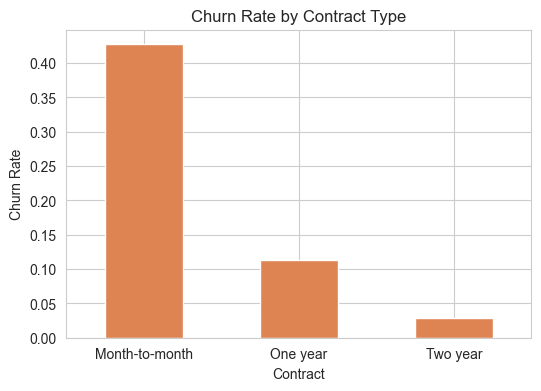

In [5]:
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_contract.plot(kind="bar", figsize=(6,4), color="#DD8452")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

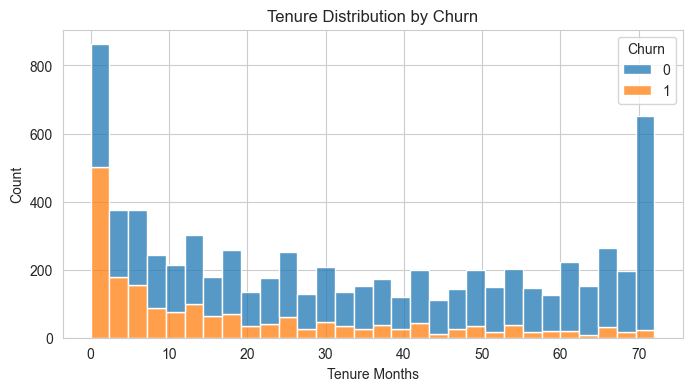

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Tenure Months", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure Distribution by Churn")
plt.show()